## STUDENT INFO: 
### 1) Name: 
##### - PRAVINRAJ A/L SIVABATHI 
##### - DHESHIEGAN SARAVANA MOORTHY
##### - AFIF SHAQIR IRFAN BIN ARQAM

### 2) Matric No:
##### - A23CS0171
##### - A23CS0072
##### - A23CS0204

### 3) Section: 03

In [ ]:
#phase 1 

In [1]:
import pandas as pd

1. **Loading two datasets into panda Dataframes**

In [100]:
# Phase I: Data Preparation & Cleaning

# 1. Load datasets
df_cars = pd.read_csv('cars_2025.csv')
df_fuel = pd.read_csv('FuelConsumption.csv')

print("Car Registrations Data Shape:", df_cars.shape)
print("Emission Data Shape:", df_fuel.shape)
print("\nSample from Car Registrations:")
print(df_cars.sample(3))
print("\nSample from Emission Data:")
print(df_fuel.sample(3))

Car Registrations Data Shape: (263578, 7)
Emission Data Shape: (1067, 13)

Sample from Car Registrations:
         date_reg                      type    maker  model colour    fuel  \
13495  2025-01-17                   motokar    Honda   City  white  petrol   
64907  2025-02-13  motokar_pelbagai_utiliti   Toyota  Veloz    red  petrol   
96156  2025-02-26                   motokar  Perodua   Myvi  white  petrol   

             state  
13495  Rakan Niaga  
64907  Rakan Niaga  
96156  Rakan Niaga  

Sample from Emission Data:
     MODELYEAR     MAKE                  MODEL VEHICLECLASS  ENGINESIZE  \
562       2014   JAGUAR                XJR LWB    FULL-SIZE         5.0   
905       2014  PORSCHE           PANAMERA GTS    FULL-SIZE         4.8   
875       2014  PORSCHE  911 CARRERA CABRIOLET  MINICOMPACT         3.4   

     CYLINDERS TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  \
562          8          AS8        Z                  15.8   
905          8          AM7        Z        

2. **Creating new columns with cleaned and standardized versions of maker and model names**

In [103]:
# 2. standardized  keys
df_cars['make_std'] = df_cars['maker'].str.upper().str.strip()
df_cars['model_std'] = df_cars['model'].str.upper().str.strip()
df_fuel['make_std'] = df_fuel['MAKE'].str.upper().str.strip()
df_fuel['model_std'] = df_fuel['MODEL'].str.upper().str.strip()

3. **Join cars with fuel using the normalized maker and model fields.**

In [9]:
# 3. Merge car registrations with emissions 
merged = df_cars.merge(
    df_fuel,
    how='left',
    on=['make_std', 'model_std']
)

print("\nMerge successful! Merged data shape:", merged.shape)


Merge successful! Merged data shape: (277343, 22)


4. **Filter out rows where no CO₂ emissions data was found**
   
   **Create a new DataFrame that only contains rows with valid CO₂ data**

In [11]:
# 4. Handle missing CO₂ values
#   a) isolate unmatched for manual review
missing_co2 = merged[ merged['CO2EMISSIONS'].isna() ]

#   b) drop rows with missing CO₂ for clean analysis
clean_data = merged.dropna(subset=['CO2EMISSIONS']).copy()

5. **Remove any completely identical rows in the clean dataset**

In [14]:
# 5. Optional: check for and drop exact duplicate rows
clean_data.drop_duplicates(inplace=True)

6. **Calculating total registration, matched and didn't match with emissions data**
7. **Compute the average CO₂ emissions for each fuel type and average emissions by state**

In [17]:
# 6. Aggregations & summaries

# 6a. Counts summary
total_regs     = len(df_cars)
matched_regs   = len(clean_data)
unmatched_regs = len(missing_co2)

print("Total registrations:   ", total_regs)
print("Matched records:       ", matched_regs)
print("Unmatched records:     ", unmatched_regs)

# 6b. Average CO₂ emissions by fuel type
avg_by_fuel = (
    clean_data
    .groupby('fuel')['CO2EMISSIONS']
    .mean()
    .sort_values()
    .reset_index()
)
print("\nAverage CO₂ by fuel type:")
print(avg_by_fuel.to_string(index=False))

# 6c. Average CO₂ emissions by state
avg_by_state = (
    clean_data
    .groupby('state')['CO2EMISSIONS']
    .mean()
    .sort_values()
    .reset_index()
)
print("\nAverage CO₂ by state:")
print(avg_by_state.to_string(index=False))


Total registrations:    263578
Matched records:        9212
Unmatched records:      251480

Average CO₂ by fuel type:
         fuel  CO2EMISSIONS
       petrol    196.747879
hybrid_petrol    200.969723
       diesel    221.150000

Average CO₂ by state:
            state  CO2EMISSIONS
           Pahang    182.205882
            Sabah    182.220930
           Perlis    182.387755
         Kelantan    183.099099
            Kedah    185.548571
       Terengganu    186.218182
           Melaka    191.977011
  Negeri Sembilan    192.200000
          Sarawak    193.130719
      Rakan Niaga    195.616549
     Pulau Pinang    197.304659
         Selangor    197.992701
            Johor    199.213542
            Perak    199.695312
W.P. Kuala Lumpur    208.012796


7. **Calculate the average emissions for every combination of state and fuel type, printing the average CO₂ by fuel type only for Pahang AND turn the hierarchical index into a pivot table**

In [21]:
# 7a. Create MultiIndex of (state, fuel) with average CO₂ emissions
mi = (
    clean_data
    .groupby(['state', 'fuel'])['CO2EMISSIONS']
    .mean()
)

# 7b. Example: Show average CO₂ emissions by fuel type for 'Pahang'
print("\nJohor CO₂ by fuel type:")
if 'Pahang' in mi.index.get_level_values('state'):
    print(mi.loc['Johor'])
else:
    print("No data available for Pahang.")

# 7c. Pivot to wide form: states as rows, fuel types as columns
emissions_table = mi.unstack()
print("\nPivot table (state × fuel) of average CO₂:")
print(emissions_table.round(2).head())



Johor CO₂ by fuel type:
fuel
hybrid_petrol    217.833333
petrol           197.520833
Name: CO2EMISSIONS, dtype: float64

Pivot table (state × fuel) of average CO₂:
fuel             diesel  hybrid_petrol  petrol
state                                         
Johor               NaN         217.83  197.52
Kedah               NaN         177.75  185.92
Kelantan            NaN         184.00  183.06
Melaka              NaN         223.00  189.26
Negeri Sembilan     NaN         198.58  190.98


8. **Put two summary tables(states and fuels)side by side**

In [25]:
# 8. Simple side-by-side summary (state & fuel CO₂ averages)

state_stats = avg_by_state.reset_index()
fuel_stats = avg_by_fuel.reset_index()

# Combine both summaries side by side
combined_stats = pd.concat([state_stats, fuel_stats], axis=1)

print("\n[8] Combined CO₂ Summary (State & Fuel Type):")
print(combined_stats.head().to_string(index=False))



[8] Combined CO₂ Summary (State & Fuel Type):
 index    state  CO2EMISSIONS  index          fuel  CO2EMISSIONS
     0   Pahang    182.205882    0.0        petrol    196.747879
     1    Sabah    182.220930    1.0 hybrid_petrol    200.969723
     2   Perlis    182.387755    2.0        diesel    221.150000
     3 Kelantan    183.099099    NaN           NaN           NaN
     4    Kedah    185.548571    NaN           NaN           NaN


## Phase II: Data Analytics and Visualization
In this section, we perform exploratory data analysis (EDA) on the merged dataset to uncover trends in fuel consumption and CO₂ emissions. We will analyze correlations, visualize key relationships, and identify high-emission vehicle categories.

1. **Represent the average CO₂ emissions per state**

In [108]:
# ——— Classification ———
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix



# 1) Grab your Phase I summary_by_state table
#    (should have cols ['state', 'CO2EMISSIONS'])
df = avg_by_state.copy()



2.  **Define a function to bucket states into 3 categories- Low, Medium, High**

In [111]:
# 2) Classify emissions into Low, Medium, or High categories
def classify_emission_level(co2):
    if co2 < 150:
        return 'Low'
    elif co2 < 200:
        return 'Medium'
    else:
        return 'High'

df['CO2_CATEGORY'] = df['CO2EMISSIONS'].apply(classify_emission_level)




3. **Treating state as the input feature and CO2_CATEGORY as the target/output**

In [114]:
# 3) Define input features and target variable
X_raw = df[['state']]
y = df['CO2_CATEGORY']



4. **Use OneHotEncoder to convert state names into numbers**

In [36]:
# 4) Prepare one-hot encoder for 'state' column
state_encoder = OneHotEncoder(handle_unknown='ignore')
encoded_matrix = state_encoder.fit_transform(X_raw)  #
features_encoded = encoded_matrix.toarray()          



5. **Divide the data into Training and Testing**

In [42]:

# 5) Partition the dataset: 80% training, 20% testing
X_train_set, X_test_set, y_train_set, y_test_set = train_test_split(
    features_encoded, y, test_size=0.2, random_state=42
)



6. **Train a KNN classifier using 5 neighbors**

   **Test it and print results**

In [82]:
# 6) KNN
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_set, y_train_set)

# Predict on test data
predicted_labels = knn_classifier.predict(X_test_set)

# Get classification report as a dictionary
report_dict = classification_report(y_test_set, predicted_labels, output_dict=True)

# Convert the report dictionary to a pandas DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Round for better readability
report_df = report_df.round(2)

# Display as table
print("KNN Classification Report")
print("")
display(report_df)



KNN Classification Report



,precision,recall,f1-score,support
Medium,1.0,1.0,1.0,3.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,3.0
weighted avg,1.0,1.0,1.0,3.0


7. **Train a Support Vector Machine (SVM)**

In [91]:
# 7) Support Vector Machine (SVM)
svm = SVC(kernel='rbf', C=1.0)
svm.fit(X_train_set, y_train_set)
y_pred_svm = svm.predict(X_test_set)

# Display classification report
print("=== SVM Classification Report ===")
print()
print(classification_report(y_test_set, y_pred_svm))


=== SVM Classification Report ===

              precision    recall  f1-score   support

      Medium       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [87]:
# ——— Confusion Matrix (SVM) ———
#import matplotlib.pyplot as plt
#import seaborn as sns

#cm = confusion_matrix(y_test, y_pred_svm, labels=['Low','Medium','High'])
#plt.figure(figsize=(6,4))
#sns.heatmap(cm, annot=True, fmt='d',
#            xticklabels=['Low','Medium','High'],
#            yticklabels=['Low','Medium','High'])
#plt.title('SVM Confusion Matrix')
#plt.xlabel('Predicted')
#plt.ylabel('Actual')
#plt.tight_layout()
#plt.show()

**Sorts states by emissions**

**Picks lowest 10 and highest 10**

**Plot the graph**

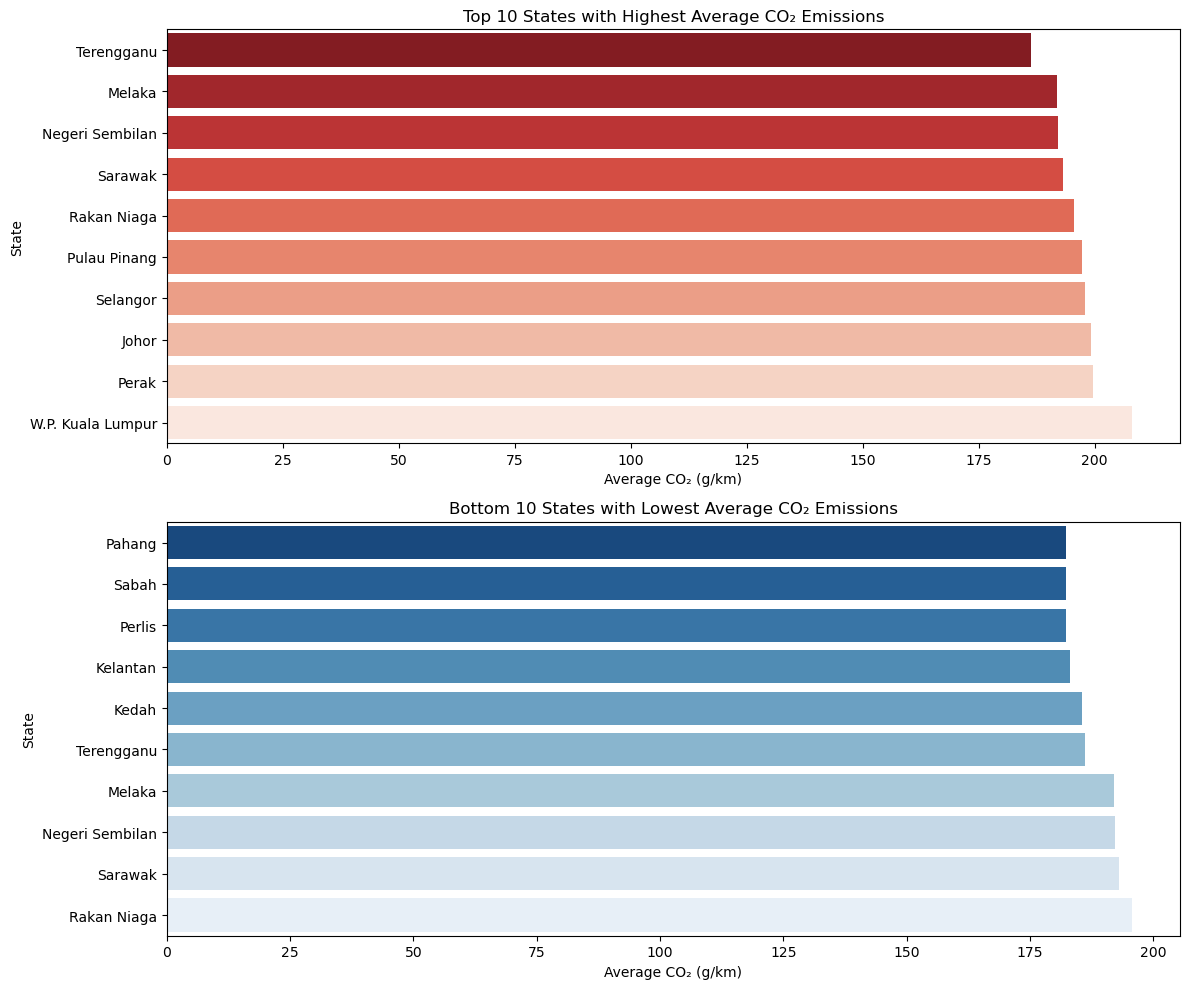

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data by CO₂ emissions
states_sorted = avg_by_state.sort_values(by='CO2EMISSIONS')
bottom10 = states_sorted.head(10)
top10 = states_sorted.tail(10)

plt.figure(figsize=(12, 10))

# Top 10 highest CO₂ emitters
plt.subplot(2, 1, 1)
sns.barplot(
    x='CO2EMISSIONS',
    y='state',
    data=top10,
    hue='state',        # Set hue to suppress warning
    dodge=False,
    palette='Reds_r',
    legend=False        # Hide legend since hue is only for color
)
plt.title('Top 10 States with Highest Average CO₂ Emissions')
plt.xlabel('Average CO₂ (g/km)')
plt.ylabel('State')

# Bottom 10 lowest CO₂ emitters
plt.subplot(2, 1, 2)
sns.barplot(
    x='CO2EMISSIONS',
    y='state',
    data=bottom10,
    hue='state',        # Same fix here
    dodge=False,
    palette='Blues_r',
    legend=False
)
plt.title('Bottom 10 States with Lowest Average CO₂ Emissions')
plt.xlabel('Average CO₂ (g/km)')
plt.ylabel('State')

plt.tight_layout()
plt.show()


**Remake the CO₂ category and set a MultiIndex using both state and CO2_CATEGORY**

In [95]:
# Recreate DataFrame with CO2_CATEGORY column
df = avg_by_state.copy()
df['CO2_CATEGORY'] = df['CO2EMISSIONS'].apply(classify_emission_level)

# Set MultiIndex with 'state' and 'CO2_CATEGORY'
multi_idx = df.set_index(['state', 'CO2_CATEGORY'], inplace=False)
multi_idx


,,CO2EMISSIONS
state,CO2_CATEGORY,
Pahang,Medium,182.205882
Sabah,Medium,182.220930
Perlis,Medium,182.387755
Kelantan,Medium,183.099099
Kedah,Medium,185.548571
Terengganu,Medium,186.218182
Melaka,Medium,191.977011
Negeri Sembilan,Medium,192.200000
Sarawak,Medium,193.130719
